In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [2]:
X, y = make_moons(100, noise=0.25,random_state=2)

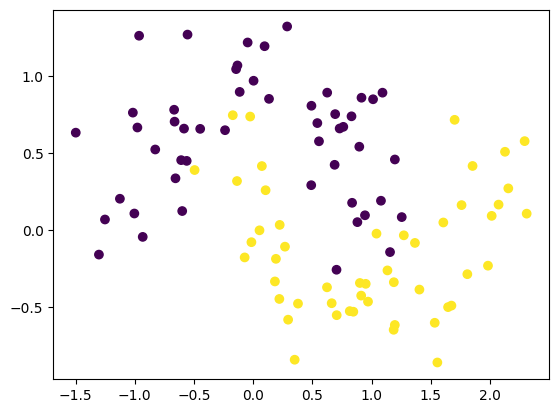

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [4]:
model1 = Sequential()

model1.add(Dense(128,input_dim=2, activation="relu"))
model1.add(Dense(128, activation="relu"))
model1.add(Dense(1,activation='sigmoid'))

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
adam = Adam(learning_rate=0.01)
model1.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history1 = model1.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


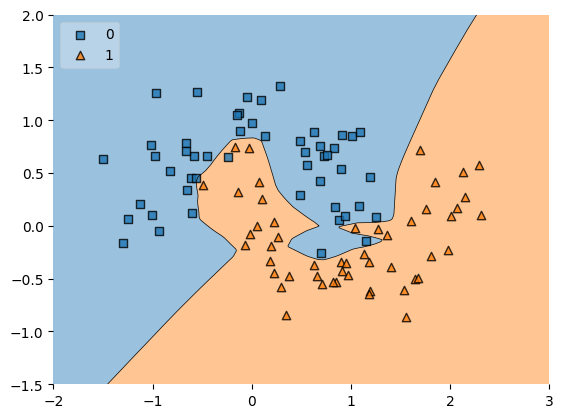

In [6]:
plot_decision_regions(X, y.astype('int'), clf=model1, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

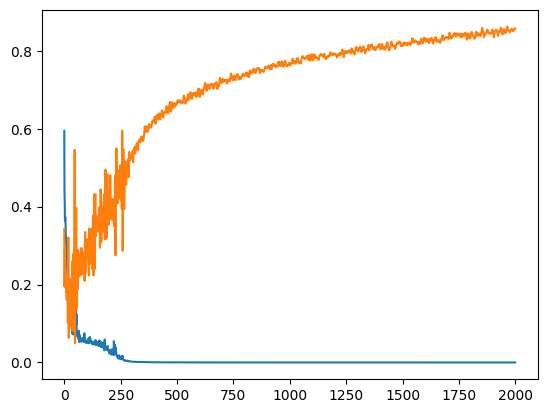

In [7]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

In [8]:
model2 = Sequential()

model2.add(Dense(128,input_dim=2, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l1(0.001)))
model2.add(Dense(128, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l1(0.001)))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
adam = Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history2 = model2.fit(X, y, epochs=2000, validation_split = 0.2,verbose=1)

Epoch 1/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - accuracy: 0.7977 - loss: 1.8767 - val_accuracy: 0.8500 - val_loss: 1.3977
Epoch 2/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7711 - loss: 1.4049 - val_accuracy: 0.9000 - val_loss: 0.9899
Epoch 3/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8523 - loss: 1.0599 - val_accuracy: 0.9000 - val_loss: 0.7553
Epoch 4/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8406 - loss: 0.8659 - val_accuracy: 0.9000 - val_loss: 0.7012
Epoch 5/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8250 - loss: 0.8019 - val_accuracy: 0.9000 - val_loss: 0.6589
Epoch 6/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8719 - loss: 0.6576 - val_accuracy: 0.9000 - val_loss: 0.5985
Epoch 7/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8422 - loss: 0.6834 - val_accuracy: 0.9000 - val_loss: 0.5707
Epoch 8/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8148 - loss: 0.6627 - val_accuracy: 0.9000 - 

In [11]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)
history2 = model2.fit(X, y, epochs=2000, validation_split = 0.2,callbacks=[early_stop],verbose=1)

Epoch 1/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9820 - loss: 0.1049 - val_accuracy: 0.9500 - val_loss: 0.3763
Epoch 2/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9836 - loss: 0.0830 - val_accuracy: 0.9500 - val_loss: 0.3860
Epoch 3/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9641 - loss: 0.1071 - val_accuracy: 0.9500 - val_loss: 0.3760
Epoch 4/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9820 - loss: 0.1078 - val_accuracy: 0.9500 - val_loss: 0.3859
Epoch 5/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9758 - loss: 0.1029 - val_accuracy: 0.9500 - val_loss: 0.4143
Epoch 6/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9937 - loss: 0.0852 - val_accuracy: 0.9500 - val_loss: 0.4199
Epoch 7/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9820 - loss: 0.1028 - val_accuracy: 0.9500 - val_loss: 0.4105
Epoch 8/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9820 - loss: 0.0987 - val_accuracy: 0.9500 - v

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


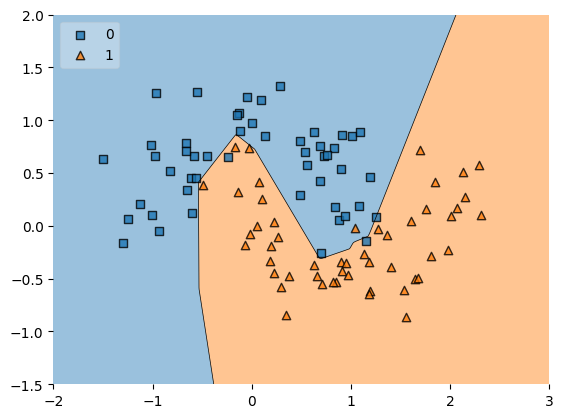

In [12]:
plot_decision_regions(X, y.astype('int'), clf=model2, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

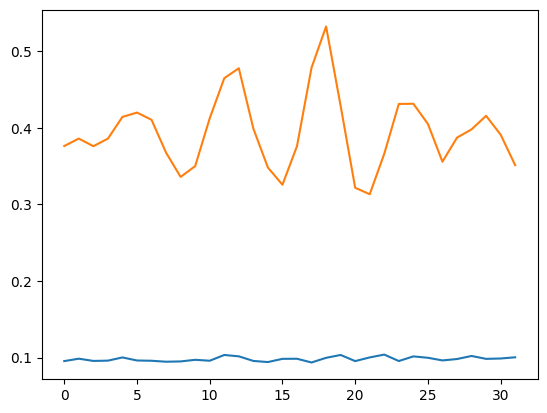

In [15]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

In [16]:
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)

<Axes: >

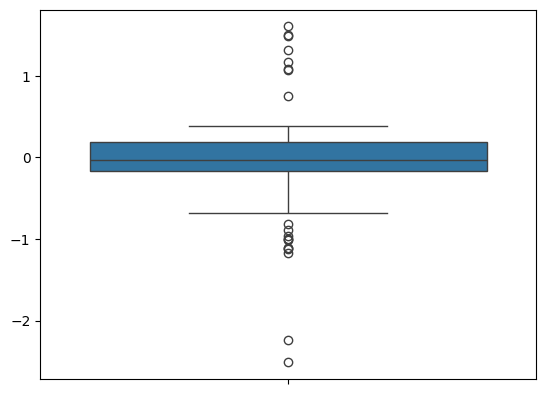

In [17]:
sns.boxplot(model1_weight_layer1)

<Axes: >

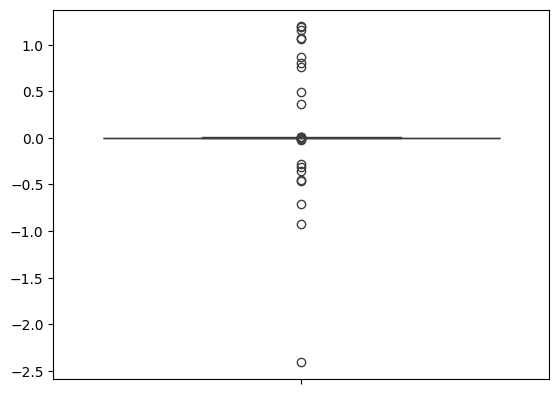

In [18]:
sns.boxplot(model2_weight_layer1)

In [19]:
model1_weight_layer1.min()

np.float32(-2.5129712)

In [20]:
model2_weight_layer1.min()

np.float32(-2.4093843)

/tmp/ipython-input-2224180084.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model1_weight_layer1)
/tmp/ipython-input-2224180084.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model2_weight_layer1)


<Axes: ylabel='Density'>

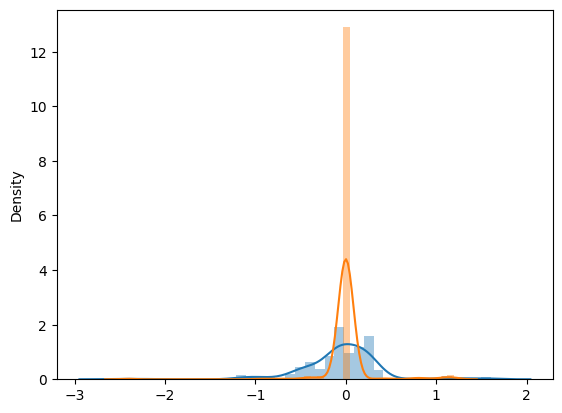

In [21]:
sns.distplot(model1_weight_layer1)
sns.distplot(model2_weight_layer1)

In [22]:
model1.get_weights()[0].reshape(256)

array([-4.64217454e-01, -5.38484514e-01, -5.61775565e-01,  1.06926441e-01,
       -3.95305276e-01, -2.45138541e-01, -3.33317786e-01,  2.06270501e-01,
       -4.79665212e-02,  2.08019659e-01, -4.46251214e-01, -5.57993293e-01,
       -3.92972618e-01,  2.01299399e-01,  2.27717698e-01, -4.89701360e-01,
       -4.93972957e-01,  9.72509235e-02,  7.91510567e-02, -1.14881776e-01,
       -9.83675346e-02,  1.16844997e-01,  2.10043713e-01, -1.69919953e-01,
       -1.39740393e-01, -4.63615984e-01, -7.30462074e-02,  1.13553874e-01,
       -3.77728552e-01, -4.77036446e-01, -8.84470865e-02, -1.53917432e-01,
        2.75621384e-01,  2.66328990e-01,  1.70014307e-01,  2.62427807e-01,
       -1.98065594e-01, -4.34099287e-01, -2.45987028e-01,  2.67897427e-01,
        2.86196768e-01, -2.60415941e-01,  3.76654416e-01, -3.21993619e-01,
        2.50571668e-01,  1.17472492e-01, -3.81449535e-02, -4.46737438e-01,
        9.52854380e-02,  2.62174726e-01, -9.98603478e-02,  1.99383497e-01,
       -3.14454019e-01,  